# Steam Games EDA

This notebook explores the Steam games dataset and prepares the ground for a later clustering project. The focus here is understanding data quality, variable distributions, and which features are likely to be useful for unsupervised segmentation.

In [1]:
import csv

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_colwidth", 120)
sns.set_theme(style="whitegrid")

In [ ]:
from pathlib import Path

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "data" / "games.csv").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_DIR = PROJECT_ROOT / "data"


## 0. Load data safely

The raw CSV header is slightly malformed: `Discount` and `DLC count` were merged into one header label, while the data rows still contain both fields. That makes a normal `pd.read_csv()` shift the columns. The helper below repairs the header before creating the DataFrame.

In [2]:
NUMERIC_COLS = [
    "Peak CCU",
    "Required age",
    "Price",
    "Discount",
    "DLC count",
    "Metacritic score",
    "User score",
    "Positive",
    "Negative",
    "Score rank",
    "Achievements",
    "Recommendations",
    "Average playtime forever",
    "Average playtime two weeks",
    "Median playtime forever",
    "Median playtime two weeks",
]

BOOL_COLS = ["Windows", "Mac", "Linux"]


def load_games_csv(path):
    rows = []
    with open(path, newline="", encoding="utf-8") as f:
        reader = csv.reader(f)
        raw_header = next(reader)
        header = raw_header[:7] + ["Discount", "DLC count"] + raw_header[8:]

        for raw_row in reader:
            if len(raw_row) != len(header):
                raise ValueError(f"Unexpected row length {len(raw_row)}")
            rows.append(raw_row)

    df = pd.DataFrame(rows, columns=header)

    df["AppID"] = pd.to_numeric(df["AppID"], errors="coerce").astype("Int64")
    for col in NUMERIC_COLS:
        df[col] = pd.to_numeric(df[col], errors="coerce")

    for col in BOOL_COLS:
        df[col] = df[col].map({"True": True, "False": False})

    return df


df = load_games_csv(DATA_DIR / "games.csv")

print(f"Shape: {df.shape}")
df.head()

Shape: (122611, 40)


,AppID,Name,Release date,Estimated owners,Peak CCU,Required age,Price,Discount,DLC count,About the game,Supported languages,Full audio languages,Reviews,Header image,Website,Support url,Support email,Windows,Mac,Linux,Metacritic score,Metacritic url,User score,Positive,Negative,Score rank,Achievements,Recommendations,Notes,Average playtime forever,Average playtime two weeks,Median playtime forever,Median playtime two weeks,Developers,Publishers,Categories,Genres,Tags,Screenshots,Movies
0,2539430,Black Dragon Mage Playtest,"Aug 1, 2023",0 - 0,0,0,0.00,0,0,,[],[],,https://shared.akamai.steamstatic.com/store_item_assets/steam/apps/2539430/header.jpg?t=1699268702,,,,True,False,False,0,,0,0,0,NaN,0,0,,0,0,0,0,,,,,,https://shared.akamai.steamstatic.com/store_item_assets/steam/apps/2539430/ss_7d9504b958d0b143d053d31cb74b375daba338...,
1,496350,Supipara - Chapter 1 Spring Has Come!,"Jul 29, 2016",0 - 20000,0,0,5.24,65,0,"Springtime, April: when the cherry trees come into full bloom. The protagonist Yukinari Sanada has returned to his h...",['English'],[],,https://shared.akamai.steamstatic.com/store_item_assets/steam/apps/496350/header.jpg?t=1725519097,http://mangagamer.org/supipara,http://mangagamer.com,support@mangagamer.com,True,False,False,0,,0,252,3,NaN,0,231,,8,0,8,0,minori,MangaGamer,"Single-player,Steam Trading Cards,Steam Cloud,Family Sharing",Adventure,"Adventure,Visual Novel,Anime,Cute",https://shared.akamai.steamstatic.com/store_item_assets/steam/apps/496350/ss_0a5ff85870a1c2221e495b75a5c7b9e248eb324...,
2,1034400,Mystery Solitaire The Black Raven,"May 6, 2019",0 - 20000,0,0,4.99,0,0,"Immerse yourself in the most beloved, mystical and entrancing world of Edgar Allan Poe's ''The Raven!'' This work re...","['English', 'French', 'German', 'Russian']",[],,https://shared.akamai.steamstatic.com/store_item_assets/steam/apps/1034400/header.jpg?t=1687434115,https://www.facebook.com/8FloorGames/,https://www.facebook.com/8FloorGames,support@8floor.net,True,True,False,0,,0,21,3,NaN,0,0,,0,0,0,0,Somer Games,8floor,"Single-player,Family Sharing",Casual,"Casual,Card Game,Solitaire,Puzzle,Hidden Object,2D,Colorful,Stylized,Logic,Mystery,Atmospheric,Family Friendly,PvE,T...",https://shared.akamai.steamstatic.com/store_item_assets/steam/apps/1034400/ss_12d8bb27a16046fe548818dcd0f5d7d0e20381...,
3,3292190,버튜버 파라노이아 - Vtuber Paranoia,"Oct 31, 2024",0 - 20000,1,0,8.99,0,1,"synopsis 'Hello, I'm Hiyoro, a new YouTuber!' It's been three years since I've repeated such greetings. Hiyoro, who ...",['Korean'],['Korean'],,https://shared.akamai.steamstatic.com/store_item_assets/steam/apps/3292190/header.jpg?t=1742217574,,,yujingamesc@gmail.com,True,False,False,0,,0,0,0,NaN,19,0,The game includes the following elements. 1. General Mature Content : Revealing outfits; sexual stimulation; sexual ...,0,0,0,0,유진게임즈,유진게임즈,"Single-player,Steam Achievements,Family Sharing","Casual,Indie,Simulation",,https://shared.akamai.steamstatic.com/store_item_assets/steam/apps/3292190/ss_87f071dbf846e7832ff49d68b0d7a8b6509bcd...,
4,3631080,Maze Quest VR,"Apr 24, 2025",0 - 20000,0,0,4.99,0,0,"Its not just a Maze; its a Quest! Enter the captivating realm of Maze Quest, where each unexpected turn presents fre...",['English'],['English'],,https://shared.akamai.steamstatic.com/store_item_assets/steam/apps/3631080/2a78ae30e350862e415889f097e422855eca25b9/...,https://www.realityexpanded.com/books-games,https://www.realityexpanded.com,support@realityexpanded.com,True,False,False,0,,0,0,0,NaN,0,0,,0,0,0,0,Reality Expanded LLC,Reality Expanded LLC,"Single-player,VR Only,Steam Leaderboards,Family Sharing","Action,Early Access",,https://shared.akamai.steamstatic.com/store_item_assets/steam/apps/3631080/3c3874df57f1a1a1f544e81ee21581f8b52140b5/...,


## 1. Dataset overview

Start with the schema, data types, and a quick look at missing values. This helps separate descriptive columns from likely modeling features.

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 122611 entries, 0 to 122610
Data columns (total 40 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   AppID                       122611 non-null  Int64  
 1   Name                        122611 non-null  str    
 2   Release date                122611 non-null  str    
 3   Estimated owners            122611 non-null  str    
 4   Peak CCU                    122611 non-null  int64  
 5   Required age                122611 non-null  int64  
 6   Price                       122611 non-null  float64
 7   Discount                    122611 non-null  int64  
 8   DLC count                   122611 non-null  int64  
 9   About the game              122611 non-null  str    
 10  Supported languages         122611 non-null  str    
 11  Full audio languages        122611 non-null  str    
 12  Reviews                     122611 non-null  str    
 13  Header image             

In [4]:
missing = (
    df.isna().sum()
    .sort_values(ascending=False)
    .to_frame("missing_count")
)
missing["missing_pct"] = (missing["missing_count"] / len(df) * 100).round(2)
missing.head(15)

,missing_count,missing_pct
Score rank,122571,99.97
AppID,0,0.00
Name,0,0.00
User score,0,0.00
Positive,0,0.00
Negative,0,0.00
Achievements,0,0.00
Recommendations,0,0.00
Notes,0,0.00
Average playtime forever,0,0.00


## 2. Feature groups

For clustering, the most promising columns are likely to be:

- Structured metadata: `Price`, `Required age`, `Windows`, `Mac`, `Linux`
- Multi-label text-like fields: `Categories`, `Genres`, `Tags`
- Possibly publisher/developer fields, if grouped carefully

Some columns are likely less useful for clustering or need special care:

- High-cardinality identifiers or URLs: `AppID`, `Header image`, `Website`, `Support url`
- Sparse text fields: `Reviews`, `Notes`
- Outcome-style variables that describe success after release: `Positive`, `Negative`, `Recommendations`, `Peak CCU`, playtime columns

In [5]:
print("Duplicate rows:", df.duplicated().sum())
print("Duplicate AppID values:", df["AppID"].duplicated().sum())
print("Duplicate Name values:", df["Name"].duplicated().sum())

Duplicate rows: 0
Duplicate AppID values: 0
Duplicate Name values: 1156


## 3. Numeric variables

Many numeric columns are heavily right-skewed, so log-scaled plots are usually more informative than raw histograms.

In [6]:
numeric_cols = [
    "Price",
    "Required age",
    "Peak CCU",
    "Positive",
    "Negative",
    "Recommendations",
    "Average playtime forever",
    "Achievements",
    "Metacritic score",
]

df[numeric_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
Price,122611.0,4.765091,12.531030,0.0,0.55,2.24,5.24,999.98
Required age,122611.0,0.167611,1.653591,0.0,0.00,0.00,0.00,21.00
Peak CCU,122611.0,54.593324,3729.451567,0.0,0.00,0.00,0.00,1013936.00
Positive,122611.0,1044.986135,28091.729937,0.0,0.00,5.00,37.00,7642084.00
Negative,122611.0,169.197429,5374.644880,0.0,0.00,1.00,10.00,1173003.00
Recommendations,122611.0,961.824967,21878.803992,0.0,0.00,0.00,0.00,4830455.00
Average playtime forever,122611.0,208.023220,11217.684738,0.0,0.00,0.00,0.00,3429544.00
Achievements,122611.0,18.087015,141.493879,0.0,0.00,2.00,19.00,9821.00
Metacritic score,122611.0,2.564941,13.660559,0.0,0.00,0.00,0.00,97.00


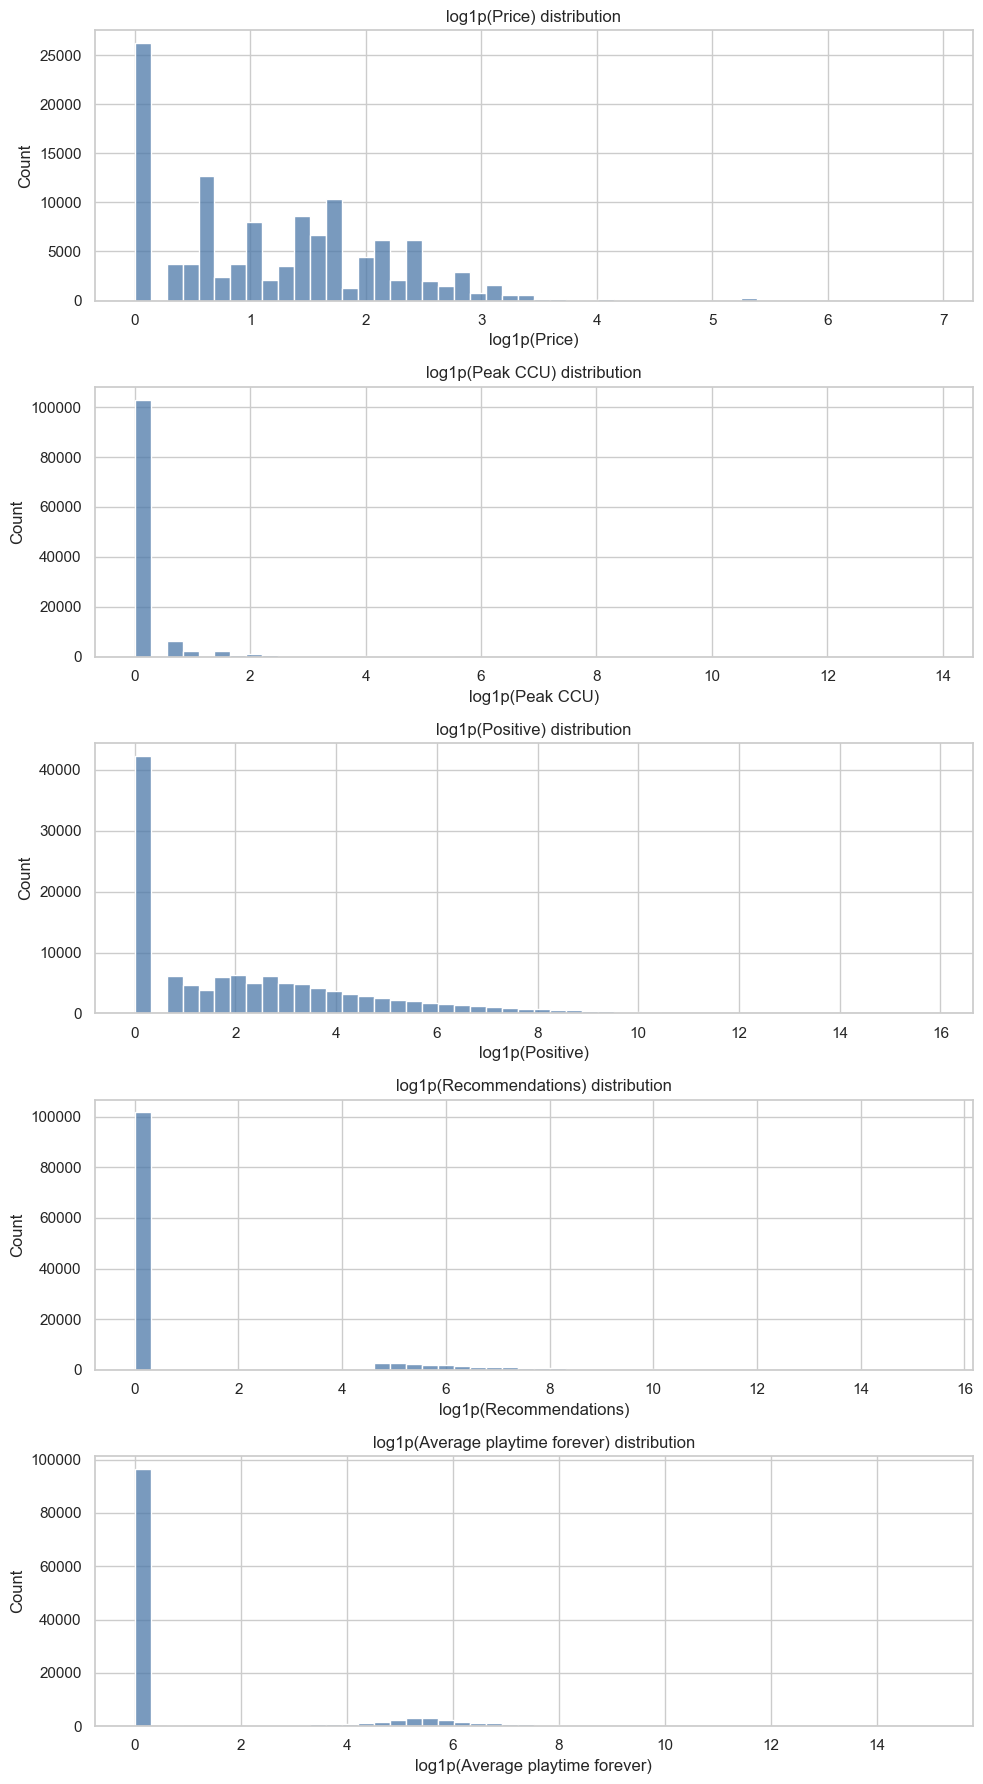

In [7]:
plot_cols = ["Price", "Peak CCU", "Positive", "Recommendations", "Average playtime forever"]

fig, axes = plt.subplots(len(plot_cols), 1, figsize=(10, 18))

for ax, col in zip(axes, plot_cols):
    values = np.log1p(df[col].fillna(0))
    sns.histplot(values, bins=50, ax=ax, color="#4C78A8")
    ax.set_title(f"log1p({col}) distribution")
    ax.set_xlabel(f"log1p({col})")

plt.tight_layout()

In [8]:
platform_counts = df[["Windows", "Mac", "Linux"]].sum().sort_values(ascending=False)
platform_counts

Windows    122567
Mac         21292
Linux       15706
dtype: int64

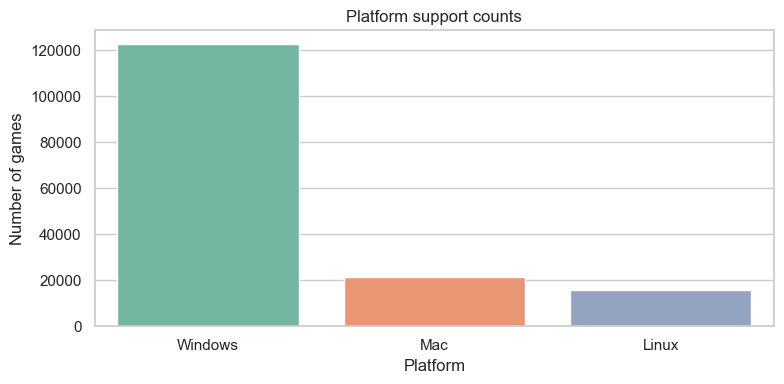

In [9]:
plt.figure(figsize=(8, 4))
sns.barplot(x=platform_counts.index, y=platform_counts.values, hue=platform_counts.index, palette="Set2", legend=False)
plt.title("Platform support counts")
plt.xlabel("Platform")
plt.ylabel("Number of games")
plt.tight_layout()

## 4. Categorical and multi-label columns

The most informative content for clustering is likely hidden inside comma-separated fields such as `Genres`, `Categories`, and `Tags`.

In [10]:
def split_items(series):
    return (
        series.dropna()
        .astype(str)
        .str.split(",")
        .explode()
        .str.strip()
        .loc[lambda s: s.ne("")]
    )

In [11]:
top_genres = split_items(df["Genres"]).value_counts().head(15)
top_categories = split_items(df["Categories"]).value_counts().head(15)
top_tags = split_items(df["Tags"]).value_counts().head(20)

display(top_genres.to_frame("count"))
display(top_categories.to_frame("count"))
display(top_tags.to_frame("count"))

,count
Genres,
Indie,80630
Casual,50210
Action,46220
Adventure,45141
Simulation,24114
Strategy,22400
RPG,20972
Free To Play,12172
Early Access,11091


,count
Categories,
Single-player,108003
Family Sharing,95904
Steam Achievements,55736
Steam Cloud,30354
Full controller support,25467
Multi-player,20294
Partial Controller Support,13691
PvP,12597
Steam Trading Cards,11377


,count
Tags,
Singleplayer,50350
Indie,48552
Action,36809
Casual,36564
Adventure,35196
2D,26792
3D,17996
Simulation,17893
Strategy,17848


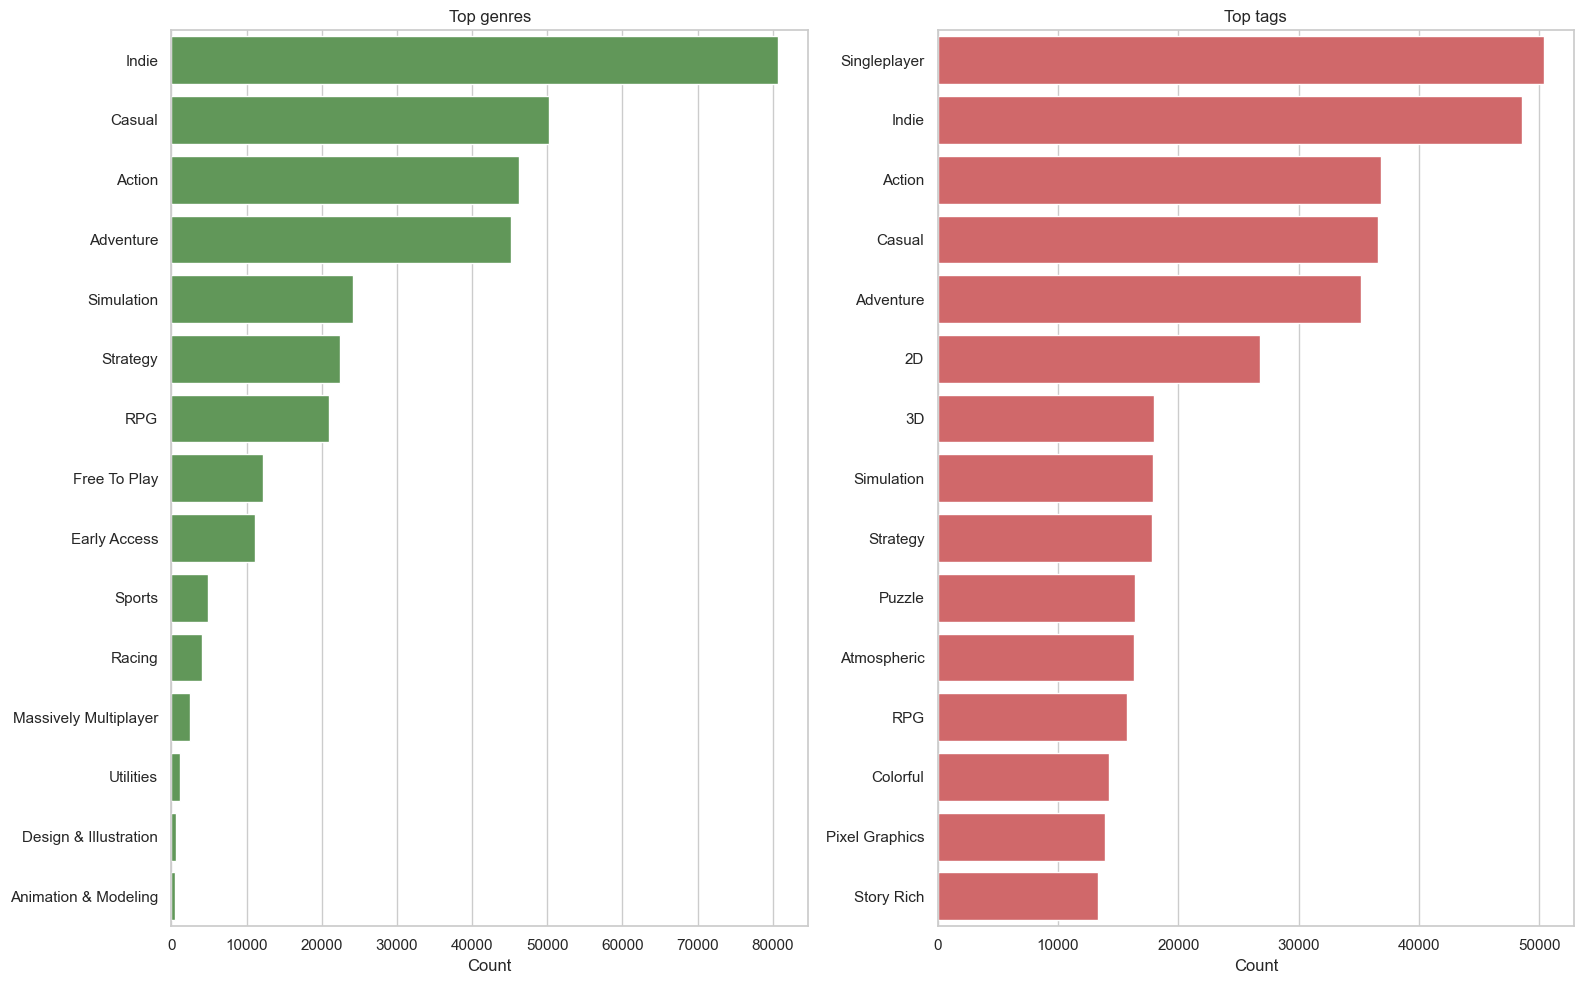

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(16, 10))

sns.barplot(x=top_genres.values, y=top_genres.index, ax=axes[0], color="#59A14F")
axes[0].set_title("Top genres")
axes[0].set_xlabel("Count")
axes[0].set_ylabel("")

sns.barplot(x=top_tags.values[:15], y=top_tags.index[:15], ax=axes[1], color="#E15759")
axes[1].set_title("Top tags")
axes[1].set_xlabel("Count")
axes[1].set_ylabel("")

plt.tight_layout()

## 5. Release dates

Release dates may help describe the market over time, even if we do not use them directly in clustering.

In [13]:
df["Release date parsed"] = pd.to_datetime(df["Release date"], format="%b %d, %Y", errors="coerce")
df["Release year"] = df["Release date parsed"].dt.year

print("Parsed release dates:", df["Release date parsed"].notna().sum())
print("Missing parsed dates:", df["Release date parsed"].isna().sum())
df[["Release date", "Release date parsed", "Release year"]].head()

Parsed release dates: 122611
Missing parsed dates: 0


,Release date,Release date parsed,Release year
0,"Aug 1, 2023",2023-08-01,2023
1,"Jul 29, 2016",2016-07-29,2016
2,"May 6, 2019",2019-05-06,2019
3,"Oct 31, 2024",2024-10-31,2024
4,"Apr 24, 2025",2025-04-24,2025


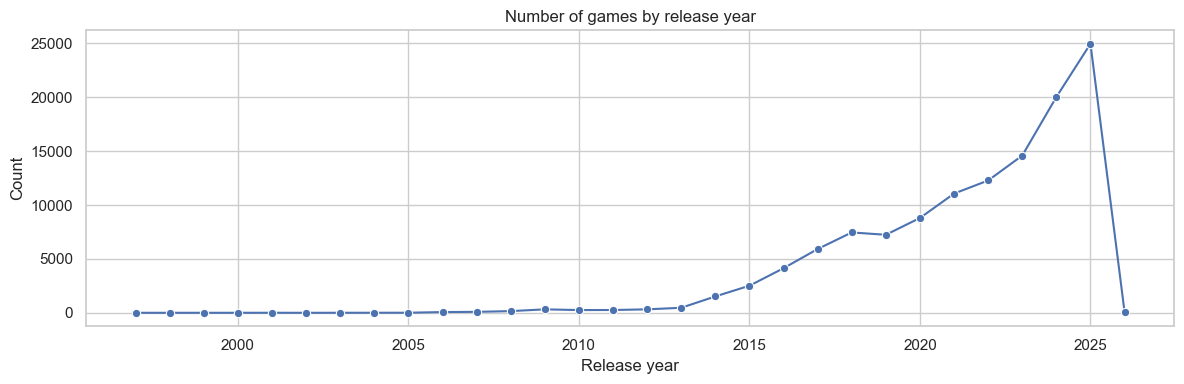

In [14]:
release_year_counts = df["Release year"].dropna().astype(int).value_counts().sort_index()

plt.figure(figsize=(12, 4))
sns.lineplot(x=release_year_counts.index, y=release_year_counts.values, marker="o")
plt.title("Number of games by release year")
plt.xlabel("Release year")
plt.ylabel("Count")
plt.tight_layout()

## 6. Numeric relationships

This correlation view is not for prediction yet. It is mainly useful for spotting redundant or outcome-heavy variables that should probably be excluded from clustering.

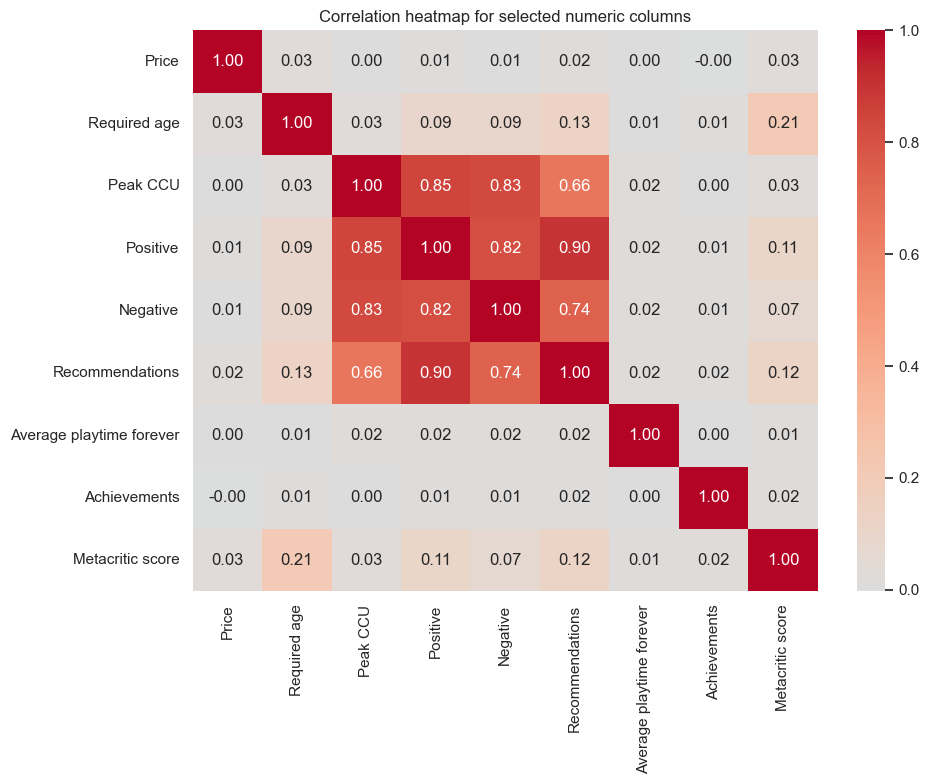

In [15]:
corr_cols = [
    "Price",
    "Required age",
    "Peak CCU",
    "Positive",
    "Negative",
    "Recommendations",
    "Average playtime forever",
    "Achievements",
    "Metacritic score",
]

corr = df[corr_cols].corr(numeric_only=True)

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation heatmap for selected numeric columns")
plt.tight_layout()

## 7. EDA takeaways

Likely conclusions to confirm after running the notebook:

- The dataset is large enough for clustering and visualization.
- Several metadata columns are sparse or unsuitable for direct modeling.
- `Genres`, `Tags`, and `Categories` should be central to clustering.
- Numeric engagement columns are extremely skewed and may be better used later for cluster interpretation, not cluster construction.
- A good next step is to build a feature matrix from multi-label metadata plus a small number of standardized numeric features, then test dimensionality reduction and clustering.